# **1) RUN THE FOLLOWING CODE BLOCKS AS IS**

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import pytorch_lightning as pl
from pytorch_lightning import LightningModule
from transformers import MistralModel, MistralConfig
from filterpy.kalman import KalmanFilter

# Set random seeds for reproducibility
seed = 42
global rng 
rng = np.random.default_rng(seed)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
# 2. System Dynamics Model (LTI Filtering System)

class FilterSim:
    """
    LTI system simulator with configurable dynamics.

    Parameters:
    - nx: state dimension
    - ny: output dimension
    - sigma_w: process noise std
    - sigma_v: measurement noise std
    - A: system matrix (if None, will be randomly generated)
    - C: output matrix (if None, will be randomly generated)
    """

    def __init__(self, nx=10, ny=5, sigma_w=0.1, sigma_v=0.1, A=None, B=None, C=None,
                 eig_low=0.5, eig_high=0.8, input_lower=0.0, input_upper=1.0):
        self.nx = nx
        self.ny = ny
        self.sigma_w = sigma_w
        self.sigma_v = sigma_v
        self.input_lower = input_lower
        self.input_upper = input_upper

        # Generate random stable system matrix if not provided
        if A is None:
            self.A = self._generate_random_stable_matrix(nx, eig_low=eig_low, eig_high=eig_high)
        else:
            self.A = A

        # Generate random controllable matrix if not provided
        if B is None:
            self.B = self._generate_controllable_B(nx, self.A)
        else:
            self.B = B

        # Generate random observable matrix if not provided
        if C is None:
            self.C = self._generate_observable_C(nx, ny, self.A)
        else:
            self.C = C

    @staticmethod
    def _generate_random_stable_matrix(n, eig_low=0.5, eig_high=0.8, max_tries=1000):
        """Generate a random stable matrix with eigenvalues in [eig_low, eig_high]"""
        for _ in range(max_tries):
            # Generate random eigenvalues in the stable region
            eigs = rng.uniform(eig_low, eig_high, size=n)
            Lambda = np.diag(eigs)

            # Generate random invertible matrix
            P = rng.standard_normal(size=(n,n))
            if np.linalg.matrix_rank(P) == n:
                A = P @ Lambda @ np.linalg.inv(P)
                # Check spectral radius for stability
                if np.max(np.abs(np.linalg.eigvals(A))) < 0.95:
                    return A

        # Fallback: diagonal matrix
        return np.diag(rng.uniform(eig_low, eig_high, size=n))
    
    @staticmethod
    def _generate_controllable_B(nx, A):
        """Generate a random B matrix that ensures controllability"""
        for _ in range(100):
            B = rng.standard_normal(size=(nx,nx))
            # Check controllability matrix rank
            CO = np.concatenate([np.linalg.matrix_power(A, i) @ B for i in range(nx)], axis=1)
            if np.linalg.matrix_rank(CO) == nx:
                return B.astype(np.float32)
        raise RuntimeError("Could not generate controllable B matrix")

    @staticmethod
    def _generate_observable_C(nx, ny, A):
        """Generate a random C matrix that ensures observability"""
        for _ in range(100):
            C = rng.standard_normal(size=(ny, nx))
            # Check observability matrix rank
            O = np.concatenate([C @ np.linalg.matrix_power(A, i)
                              for i in range(nx)], axis=0)
            if np.linalg.matrix_rank(O) == nx:
                return C.astype(np.float32)
        raise RuntimeError("Could not generate observable C matrix")

    def simulate(self, traj_len, x0=None, input_lower=None, input_upper=None):
        """
        Simulate a trajectory.

        Args:
            traj_len: number of time steps
            x0: initial state (if None, random)
            input_lower: lower bound for control inputs (if None, uses self.input_lower)
            input_upper: upper bound for control inputs (if None, uses self.input_upper)

        Returns:
            states: (traj_len+1, nx) array of states
            outputs: (traj_len+1, ny) array of noisy observations
            inputs: (traj_len, nx) array of control inputs
        """
        nx, ny = self.nx, self.ny

        # Use instance defaults if not provided
        if input_lower is None:
            input_lower = self.input_lower
        if input_upper is None:
            input_upper = self.input_upper

        # Initialize
        x = rng.standard_normal(size=nx) if x0 is None else x0
        states = [x]
        outputs = [self.C @ x + rng.standard_normal(ny) * self.sigma_v]
        inputs = []

        for _ in range(traj_len):
            # Generate random control input
            u = rng.multivariate_normal(input_lower*np.ones(nx), np.diag(input_upper*np.ones(nx)))
            inputs.append(u)

            # State transition with process noise
            x = self.A @ x + self.B @ u + rng.standard_normal(size=nx) * self.sigma_w
            states.append(x)

            # Observation with measurement noise
            y = self.C @ x + rng.standard_normal(size=ny) * self.sigma_v
            outputs.append(y)

        return (np.array(states, dtype=np.float32),
                np.array(outputs, dtype=np.float32),
                np.array(inputs, dtype=np.float32))

def apply_kalman_filter(fsim, obs, inputs=None, x0=None, P0=None, sigma_w=None, sigma_v=None):
    """
    Apply Kalman filter to a trajectory's observations with control inputs.

    Args:
        fsim: FilterSim instance with A and C matrices
        obs: (traj_len+1, ny) array of noisy observations
        inputs: (traj_len, nx) array of control inputs (if None, assumes no control)
        x0: initial state estimate (if None, uses zeros)
        P0: initial covariance (if None, uses identity)
        sigma_w: process noise (if None, uses fsim.sigma_w)
        sigma_v: measurement noise (if None, uses fsim.sigma_v)

    Returns:
        kf_states: (traj_len+1, nx) array of Kalman filter state estimates
    """
    ny, nx = fsim.C.shape

    sigma_w = fsim.sigma_w if sigma_w is None else sigma_w
    sigma_v = fsim.sigma_v if sigma_v is None else sigma_v

    kf = KalmanFilter(dim_x=nx, dim_z=ny)
    kf.Q = np.eye(nx) * sigma_w ** 2
    kf.R = np.eye(ny) * sigma_v ** 2
    kf.P = np.eye(nx) if P0 is None else P0
    kf.x = np.zeros(nx) if x0 is None else x0
    kf.F = fsim.A
    kf.H = fsim.C

    # Control matrix B
    kf.B = fsim.B

    # Store predictions
    kf_states = []

    # Process first observation y_0 to estimate x_0
    if len(obs) > 0:
        kf.update(obs[0])
        kf_states.append(kf.x.copy())

    # Process remaining observations: predict with u_i, update with y_{i+1}
    for i in range(len(inputs)):
        if inputs is not None and i < len(inputs):
            kf.predict(u=inputs[i])
        else:
            kf.predict()
        kf.update(obs[i+1])
        kf_states.append(kf.x.copy())

    return np.array(kf_states, dtype=np.float32)


def apply_kalman_filter_from_traj(traj):
    """
    Apply Kalman filter to a trajectory dictionary.

    Args:
        traj: trajectory dictionary with 'obs', 'inputs', 'A', 'C' (and optionally 'sigma_w', 'sigma_v')

    Returns:
        kf_states: (traj_len+1, nx) array of Kalman filter state estimates
    """
    # Create a FilterSim instance with the trajectory's parameters
    nx = traj['A'].shape[0]
    ny = traj['C'].shape[0]

    # Get noise parameters from trajectory or use defaults
    sigma_w = traj.get('sigma_w', 0.1)
    sigma_v = traj.get('sigma_v', 0.1)

    fsim = FilterSim(nx=nx, ny=ny, sigma_w=sigma_w, sigma_v=sigma_v)
    fsim.A = traj['A']
    fsim.B = traj['B']
    fsim.C = traj['C']

    return apply_kalman_filter(fsim, traj['obs'], traj['inputs'])


In [ ]:
# 3. Dataset Preparation

class TrajectoryDataset(Dataset):
    """
    Dataset that provides trajectories for training.
    Each sample is a trajectory with states, observations, and inputs.
    """

    def __init__(self, trajectories):
        """
        Args:
            trajectories: list of trajectory dicts from generate_trajectory()
        """
        self.trajectories = trajectories

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        """
        Returns a sample dict with:
        - xs: input features (concatenated observation and input)
        - ys: target (state)
        """
        traj = self.trajectories[idx % len(self.trajectories)]

        states = traj['states']  # (traj_len+1, nx)
        obs = traj['obs']  # (traj_len+1, ny)
        inputs = traj['inputs']  # (traj_len, nx)

        # Input: [output_t, input_{t-1}], Target: state_t
        # Use noisy observations and previous input as input (filtering: estimate state from observation and input)
        xs = np.concatenate([obs[1:], inputs], axis=-1)  # (traj_len, ny+nx)
        ys = states[1:]  # (traj_len, nx)

        return {
            'xs': torch.from_numpy(xs).float(),
            'ys': torch.from_numpy(ys).float()
        }


def create_datasets(num_train=1000, num_val=200, traj_len=50,
                    nx=10, ny=5, sigma_w=0.1, sigma_v=0.1,
                    input_lower=0.0, input_upper=1.0,
                    eig_low=0.5, eig_high=0.9, A=None, B=None, C=None):
    """
    Create training and validation datasets.

    Returns:
        train_dataset, val_dataset
    """
    print("Generating training trajectories...")
    train_traj = [
        generate_trajectory(nx=nx, ny=ny, traj_len=traj_len,
                           sigma_w=sigma_w, sigma_v=sigma_v,
                           input_lower=input_lower, input_upper=input_upper,
                           A=A, B=B, C=C, eig_low=eig_low, eig_high=eig_high)
        for _ in tqdm(range(num_train))
    ]

    print("Generating validation trajectories...")
    val_traj = [
        generate_trajectory(nx=nx, ny=ny, traj_len=traj_len,
                           sigma_w=sigma_w, sigma_v=sigma_v,
                           input_lower=input_lower, input_upper=input_upper,
                           A=A, B=B, C=C, eig_low=eig_low, eig_high=eig_high)
        for _ in tqdm(range(num_val))
    ]
    return TrajectoryDataset(train_traj), TrajectoryDataset(val_traj)


def generate_trajectory(nx=10, ny=5, traj_len=50, sigma_w=0.1, sigma_v=0.1,
                         input_lower=0.0, input_upper=1.0, A=None, B=None, C=None,
                         eig_low=0.5, eig_high=0.8):
    """
    Generate a single trajectory with configurable parameters.

    Returns:
        dict with 'states', 'obs', 'inputs', 'A', 'C', 'sigma_w', 'sigma_v'
    """
    fsim = FilterSim(nx=nx, ny=ny, sigma_w=sigma_w, sigma_v=sigma_v, A=A, B=B, C=C,
                     eig_low=eig_low, eig_high=eig_high,
                     input_lower=input_lower, input_upper=input_upper)
    states, obs, inputs = fsim.simulate(traj_len, input_lower=input_lower, input_upper=input_upper)

    return {
        'states': states,
        'obs': obs,
        'inputs': inputs,
        'A': fsim.A,
        'B': fsim.B,
        'C': fsim.C,
        'sigma_w': sigma_w,
        'sigma_v': sigma_v
    }


In [ ]:
# 4. Mistral Transformer Model

class Mistral7BFilter(LightningModule):
    """
    Transformer model using HuggingFace Mistral for sequence prediction.
    Trained with PyTorch Lightning.
    """

    def __init__(self, input_dim, output_dim, n_positions=50,
                 n_embd=128, n_layer=6, n_head=4, dropout=0.15,
                 learning_rate=1e-4, weight_decay=1e-4, gradient_clip=1.0):
        """
        Args:
            input_dim: dimension of input features
            output_dim: dimension of output (state dimension)
            n_positions: maximum sequence length
            n_embd: embedding dimension
            n_layer: number of transformer layers
            n_head: number of attention heads
            dropout: dropout rate
            learning_rate: learning rate for optimizer
            weight_decay: weight decay for optimizer
            gradient_clip: gradient clipping value
        """
        super().__init__()
        self.save_hyperparameters()

        self.input_dim = input_dim
        self.output_dim = output_dim
        self.n_positions = n_positions
        self.n_embd = n_embd
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.gradient_clip = gradient_clip

        # Input embedding (projects input features to embedding dimension)
        self.embed = nn.Linear(input_dim, n_embd)

        # Mistral configuration
        mistral_config = MistralConfig(
            vocab_size=1,  # Not used, we have our own embeddings
            max_position_embeddings=n_positions,
            hidden_size=n_embd,
            num_hidden_layers=n_layer,
            num_attention_heads=n_head,
            num_key_value_heads=n_head,  # Mistral uses GQA by default
            intermediate_size=n_embd * 4,  # Typical for Mistral
            hidden_dropout=dropout,
            attention_dropout=dropout,
            use_cache=False,
        )

        # Mistral model (without the final LM head)
        self.transformer = MistralModel(mistral_config)

        # Output projection
        self.output_proj = nn.Linear(n_embd, output_dim)

        # Loss function
        self.criterion = nn.MSELoss()

    def forward(self, xs):
        """
        Args:
            xs: (batch_size, seq_len, input_dim) input tensor

        Returns:
            preds: (batch_size, seq_len, output_dim) predictions
        """
        batch_size, seq_len, _ = xs.shape

        # Input embedding
        x = self.embed(xs)

        # Truncate if sequence is too long
        if seq_len > self.n_positions:
            x = x[:, -self.n_positions:]

        # Mistral expects inputs_embeds, not tokenizer input
        # Mistral has built-in positional embeddings and causal mask
        output = self.transformer(inputs_embeds=x).last_hidden_state

        # Output projection
        preds = self.output_proj(output)

        return preds

    def training_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']

        preds = self(xs)

        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])

        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']

        preds = self(xs)

        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])

        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True, sync_dist=True)
        return loss

    def test_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']

        preds = self(xs)

        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])

        self.log('test_loss', loss, on_step=False, on_epoch=True, sync_dist=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay
        )
        return {
            'optimizer': optimizer,
            'clip_value': self.gradient_clip,
        }


In [ ]:
# 5. Training Setup

class TransformerDataModule(pl.LightningDataModule):
    """Lightning data module for trajectory data."""

    def __init__(self, train_dataset, val_dataset=None, batch_size=32, num_workers=4):
        super().__init__()
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.batch_size = batch_size
        self.num_workers = num_workers

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=False,
            drop_last=False
        )

    def val_dataloader(self):
        if self.val_dataset is not None:
            return DataLoader(
                self.val_dataset,
                batch_size=self.batch_size,
                shuffle=False,
                num_workers=self.num_workers,
                pin_memory=False,
                drop_last=False
            )
        return None

    def test_dataloader(self):
        if hasattr(self, 'test_dataset') and self.test_dataset is not None:
            return DataLoader(
                self.test_dataset,
                batch_size=self.batch_size,
                shuffle=False,
                num_workers=self.num_workers,
                pin_memory=True,
                drop_last=False
            )
        return None


In [ ]:
def evaluate_model(model, dataset, batch_size=32):
    """
    Evaluate model on a dataset.

    Args:
        model: trained Mistral7BFilter
        dataset: TrajectoryDataset to evaluate on
        batch_size: batch size for evaluation

    Returns:
        average MSE loss
    """
    model = model.to(device)
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    criterion = nn.MSELoss()
    total_loss = 0.0
    num_batches = 0

    with torch.no_grad():
        for batch in loader:
            xs = batch['xs'].to(device)
            ys = batch['ys'].to(device)

            preds = model(xs)
            min_len = min(preds.shape[1], ys.shape[1])
            loss = criterion(preds[:, :min_len], ys[:, :min_len])

            total_loss += loss.item()
            num_batches += 1

    return total_loss / num_batches


def generate_test_trajectories(num_test=100, traj_len=50, nx=10, ny=5,
                                sigma_w=0.01, sigma_v=0.01,
                                input_lower=0.0, input_upper=1.0,
                                eig_low=0.5, eig_high=0.8, A=None, B=None, C=None):
    """
    Generate test trajectories with potentially different parameters than training.
    """
    print(f'\nGenerating {num_test} test trajectories...')
    test_traj = [
        generate_trajectory(nx=nx, ny=ny, traj_len=traj_len,
                           sigma_w=sigma_w, sigma_v=sigma_v,
                           input_lower=input_lower, input_upper=input_upper,
                           eig_low=eig_low, eig_high=eig_high,
                           A=A, B=B, C=C)
        for _ in tqdm(range(num_test))
    ]
    return test_traj


def plot_results(history, test_loss=None, save_path=None):
    """Plot training and validation loss."""
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    if 'val_loss' in history and history['val_loss']:
        plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.title('Training History')

    if test_loss is not None:
        plt.subplot(1, 2, 2)
        plt.bar(['Test Loss'], [test_loss])
        plt.title('Test Performance')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        print(f'Plot saved to {save_path}')
    else:
        try:
            plt.show()
        except:
            pass


# **2) START EDITING PARAMETERS HERE**

In [ ]:
# Configuration parameters
CONFIG = {
    # System dimensions
    'nx': 10,           # State dimension
    'ny': 5,            # Output dimension

    # Trajectory parameters
    'traj_len': 50,     # Length of each trajectory
    'num_val': 5000,     # Number of validation trajectories
    'num_test': 100,    # Number of test trajectories
    'num_train_list': [500, 1000, 5000, 10000],  # List of training trajectory counts to test

    # Noise parameters (training)
    'sigma_w_train': 0.01,  # Process noise
    'sigma_v_train': 0.01,  # Measurement noise
    'input_lower_train': 0.,  # Input lower bound (mean if Gaussian)
    'input_upper_train': 0.1,  # Input upper bound (variance if Gaussian)
    'eig_low_train': np.nextafter(0, 1),    # Eigenvalue lower bound
    'eig_high_train': 0.9,   # Eigenvalue upper bound

    # Noise parameters (testing) - can be different!
    'sigma_w_test': 0.01,    # Process noise for testing
    'sigma_v_test': 0.01,    # Measurement noise for testing
    'input_lower_test': 0.5,  # Input lower bound for testing
    'input_upper_test': 0.1,  # Input upper bound for testing
    'eig_low_test': np.nextafter(0, 1),      # Eigenvalue lower bound for testing
    'eig_high_test': 0.9,    # Eigenvalue upper bound for testing

    # Model parameters
    'n_positions': 50,   # Maximum sequence length
    'n_embd': 128,        # Embedding dimension
    'n_layer': 6,         # Number of transformer layers
    'n_head': 4,          # Number of attention heads
    'dropout': 0.15,       # Dropout rate

    # Training parameters
    'batch_size': 32,
    'num_epochs': 50,
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'gradient_clip': 1.0,
}

print("="*60)
print("TRANSFORMER FILTER (MISTRAL-7B) - VARYING TRAINING TRAJECTORIES")
print("="*60)
print(f"Configuration: {CONFIG}")
print()


In [ ]:
# Step 1: Create datasets with fixed A, B, C matrices (same for all training sizes)
print("\n[1/5] Creating fixed system matrices...")
A = np.diag(rng.uniform(np.nextafter(0,1), 0.95, size=CONFIG['nx']))
P = rng.standard_normal(size=(CONFIG['nx'], CONFIG['nx']))
while np.linalg.matrix_rank(P) != CONFIG['nx']:
    P = rng.standard_normal(size=(CONFIG['nx'], CONFIG['nx']))
A = P @ A @ np.linalg.solve(P, np.eye(CONFIG['nx']))

B = rng.standard_normal(size=(CONFIG['nx'], CONFIG['nx']))
for _ in range(100):
    B = rng.standard_normal(size=(CONFIG['nx'], CONFIG['nx']))
    CO = np.concatenate([np.linalg.matrix_power(A, i) @ B for i in range(CONFIG['nx'])], axis=1)
    if np.linalg.matrix_rank(CO) == CONFIG['nx']:
        break

C = rng.standard_normal(size=(CONFIG['ny'], CONFIG['nx']))
for _ in range(100):
    C = rng.standard_normal(size=(CONFIG['ny'], CONFIG['nx']))
    O = np.concatenate([C @ np.linalg.matrix_power(A, i)
                        for i in range(CONFIG['nx'])], axis=0)
    if np.linalg.matrix_rank(O) == CONFIG['nx']:
        break

print("System matrices created: A, B, C")
print(f"A shape: {A.shape}, B shape: {B.shape}, C shape: {C.shape}")


In [ ]:
# Step 2: Generate shared validation and test datasets (same for all models)
print("\n[2/5] Creating shared validation and test datasets...")

# Validation dataset (same for all training sizes)
_, val_dataset = create_datasets(
    num_train=CONFIG['num_train_list'][0],  # Just need a small number for val
    num_val=CONFIG['num_val'],
    traj_len=CONFIG['traj_len'],
    nx=CONFIG['nx'],
    ny=CONFIG['ny'],
    sigma_w=CONFIG['sigma_w_train'],
    sigma_v=CONFIG['sigma_v_train'],
    input_lower=CONFIG['input_lower_train'],
    input_upper=CONFIG['input_upper_train'],
    eig_low=CONFIG['eig_low_train'],
    eig_high=CONFIG['eig_high_train'],
    A=A,
    B=B,
    C=C
)

print(f"Validation dataset: {len(val_dataset)} trajectories")

# Test trajectories (same for all models)
test_trajs = generate_test_trajectories(
    num_test=CONFIG['num_test'],
    traj_len=CONFIG['traj_len'],
    nx=CONFIG['nx'],
    ny=CONFIG['ny'],
    sigma_w=CONFIG['sigma_w_test'],
    sigma_v=CONFIG['sigma_v_test'],
    input_lower=CONFIG['input_lower_test'],
    input_upper=CONFIG['input_upper_test'],
    eig_low=CONFIG['eig_low_test'],
    eig_high=CONFIG['eig_high_test'],
    A=A,
    B=B,
    C=C
)

print(f"Test trajectories: {len(test_trajs)} trajectories")


In [ ]:
# Step 3: Train models with different numbers of training trajectories
print("\n[3/5] Training models with varying training trajectory counts...")

# Dictionary to store trained models and their results
trained_models = {}
training_histories = {}

input_dim = CONFIG['ny'] + CONFIG['nx']  # observation + input dimensions
output_dim = CONFIG['nx']  # predict state

for num_train in CONFIG['num_train_list']:
    print(f"\n--- Training with {num_train} training trajectories ---")
    
    # Create training dataset with this many trajectories
    print(f"Generating {num_train} training trajectories...")
    train_traj = [
        generate_trajectory(nx=CONFIG['nx'], ny=CONFIG['ny'], traj_len=CONFIG['traj_len'],
                           sigma_w=CONFIG['sigma_w_train'], sigma_v=CONFIG['sigma_v_train'],
                           input_lower=CONFIG['input_lower_train'], input_upper=CONFIG['input_upper_train'],
                           eig_low=CONFIG['eig_low_train'], eig_high=CONFIG['eig_high_train'],
                           A=A, B=B, C=C)
        for _ in tqdm(range(num_train))
    ]
    train_dataset = TrajectoryDataset(train_traj)
    
    # Create model
    model = Mistral7BFilter(
        input_dim=input_dim,
        output_dim=output_dim,
        n_positions=CONFIG['n_positions'],
        n_embd=CONFIG['n_embd'],
        n_layer=CONFIG['n_layer'],
        n_head=CONFIG['n_head'],
        dropout=CONFIG['dropout'],
        learning_rate=CONFIG['learning_rate'],
        weight_decay=CONFIG['weight_decay'],
        gradient_clip=CONFIG['gradient_clip']
    )
    
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Create data module
    datamodule = TransformerDataModule(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        batch_size=CONFIG['batch_size'],
        num_workers=4
    )
    
    # Create trainer
    trainer = pl.Trainer(
        max_epochs=CONFIG['num_epochs'],
        devices="auto",
        accelerator="auto",
        gradient_clip_val=CONFIG['gradient_clip'],
        log_every_n_steps=10,
        enable_progress_bar=True,
        default_root_dir=".",
    )
    
    # Train
    print(f"Training model with {num_train} trajectories...")
    trainer.fit(model, datamodule=datamodule)
    
    # Get training history
    history = {
        'train_loss': [],
        'val_loss': []
    }
    print(f"Training complete. Best val loss: {trainer.callback_metrics.get('val_loss', float('inf')):.6f}")
    
    # Store model and history
    trained_models[num_train] = model
    training_histories[num_train] = history
    
    print(f"Model with {num_train} training trajectories saved.")

print("\nAll models trained successfully!")



[4/5] Testing all models on shared test set...
Evaluating on 100 test trajectories...

--- Testing model trained with 100 trajectories ---
Transformer - Avg squared error: 19.545612 +/- 3.182517
Kalman Filter - Avg squared error: 0.000313 +/- 0.000277

--- Testing model trained with 250 trajectories ---
Transformer - Avg squared error: 16.599693 +/- 2.781230
Kalman Filter - Avg squared error: 0.000269 +/- 0.000202

--- Testing model trained with 500 trajectories ---
Transformer - Avg squared error: 12.794290 +/- 2.705631
Kalman Filter - Avg squared error: 0.000384 +/- 0.000395

--- Testing model trained with 750 trajectories ---
Transformer - Avg squared error: 11.609942 +/- 2.210743
Kalman Filter - Avg squared error: 0.000333 +/- 0.000332

--- Testing model trained with 1000 trajectories ---
Transformer - Avg squared error: 11.080966 +/- 2.034551
Kalman Filter - Avg squared error: 0.000396 +/- 0.000361

--- Testing model trained with 1500 trajectories ---
Transformer - Avg squared er

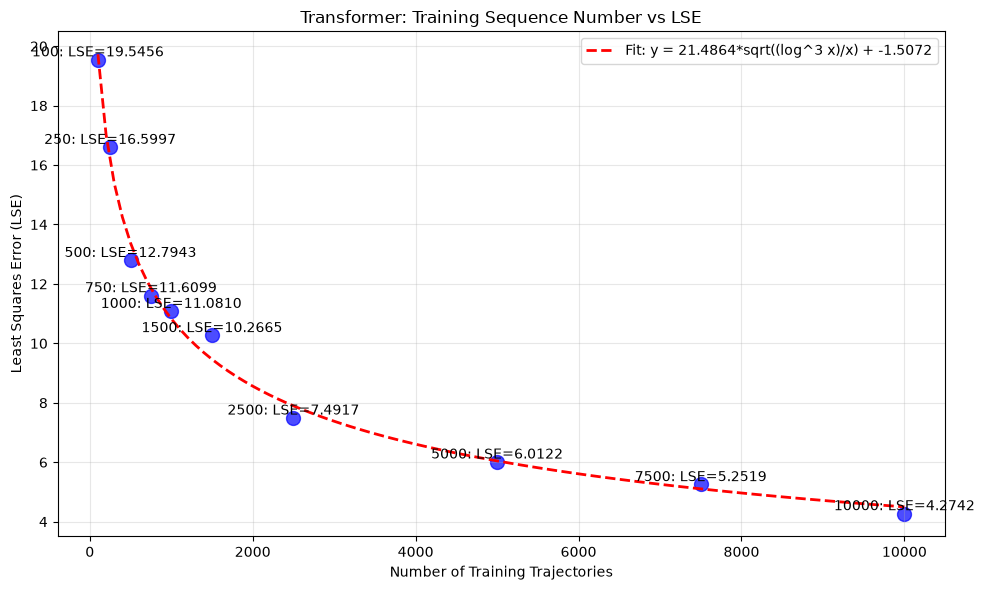

In [ ]:
# Step 4: Test each model on the shared test set
print("\n[4/5] Testing all models on shared test set...")

# Store results for each model
results = {}  # Key: num_train, Value: dict with errors and plots

# Number of test trajectories to evaluate
num_test_eval = min(100, len(test_trajs))  # Use up to 100 test trajectories
print(f"Evaluating on {num_test_eval} test trajectories...")

for num_train in CONFIG['num_train_list']:
    print(f"\n--- Testing model trained with {num_train} trajectories ---")
    
    model = trained_models[num_train]
    model = model.to(device)
    model.eval()
    
    # Lists to store errors
    all_transformer_errors = []
    all_kalman_errors = []
    
    # Sample a subset of test trajectories for evaluation
    sampled_test_indices = rng.choice(len(test_trajs), size=num_test_eval, replace=False)
    
    for traj_idx in sampled_test_indices:
        test_traj = test_trajs[traj_idx]
        states_true = test_traj['states']
        obs = test_traj['obs']
        inputs = test_traj['inputs']
        
        # Prepare input for model
        xs_for_model = np.concatenate([obs[1:], inputs], axis=-1)
        xs_tensor = torch.from_numpy(xs_for_model).float().unsqueeze(0).to(device)
        
        # Get model predictions
        with torch.no_grad():
            preds_tensor = model(xs_tensor)
        preds = preds_tensor.squeeze(0).cpu().numpy()
        
        # Get Kalman filter predictions
        kf_states = apply_kalman_filter_from_traj(test_traj)
        kf_preds = kf_states[1:]
        
        # Compute squared errors
        actual_len = min(preds.shape[0], states_true[1:].shape[0], kf_preds.shape[0])
        
        # Transformer squared error (per timestep, averaged over state dimensions)
        tf_error = np.mean((states_true[1:][:actual_len] - preds[:actual_len]) ** 2)
        all_transformer_errors.append(tf_error)
        
        # Kalman filter squared error
        kf_error = np.mean((states_true[1:][:actual_len] - kf_preds[:actual_len]) ** 2)
        all_kalman_errors.append(kf_error)
    
    # Compute summary statistics
    avg_tf_error = np.mean(all_transformer_errors)
    std_tf_error = np.std(all_transformer_errors)
    avg_kf_error = np.mean(all_kalman_errors)
    std_kf_error = np.std(all_kalman_errors)
    
    results[num_train] = {
        'avg_transformer_error': avg_tf_error,
        'std_transformer_error': std_tf_error,
        'avg_kalman_error': avg_kf_error,
        'std_kalman_error': std_kf_error,
        'all_transformer_errors': all_transformer_errors,
        'all_kalman_errors': all_kalman_errors,
        'model': model
    }
    
    print(f"Transformer - Avg squared error: {avg_tf_error:.6f} +/- {std_tf_error:.6f}")
    print(f"Kalman Filter - Avg squared error: {avg_kf_error:.6f} +/- {std_kf_error:.6f}")
    

print("\nAll models tested successfully!")


# Scatterplot: training sequence number vs LSE for Transformer
plt.figure(figsize=(10, 6))
train_counts = CONFIG['num_train_list']
tf_lse = [results[n]['avg_transformer_error'] for n in train_counts]
plt.scatter(train_counts, tf_lse, s=100, color='blue', alpha=0.7)
for i, n in enumerate(train_counts):
    plt.text(n, tf_lse[i], f'{n}: LSE={tf_lse[i]:.4f}', ha='center', va='bottom')
plt.xlabel('Number of Training Trajectories')
plt.ylabel('Least Squares Error (LSE)')
plt.title('Transformer: Training Sequence Number vs LSE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Fit curve y = a*sqrt(x) + b
from scipy.optimize import curve_fit
def fit_func(x, a, b):
        return a * np.sqrt(np.log(x) / x) + b

# Perform curve fitting
try:
    popt, pcov = curve_fit(fit_func, train_counts, tf_lse)
    a_fit, b_fit = popt
    print(f"Fitted curve: y = {a_fit:.6f} * sqrt(log x / x) + {b_fit:.6f}")
        # Calculate R^2        y_pred = fit_func(train_counts, a_fit, b_fit)        ss_res = np.sum((tf_lse - y_pred) ** 2)        ss_tot = np.sum((tf_lse - np.mean(tf_lse)) ** 2)        r_squared = 1 - (ss_res / ss_tot)        print(f"R^2 = {r_squared:.6f}")
    # Generate curve points for plotting
    x_curve = np.linspace(min(train_counts), max(train_counts), 100)
    y_curve = fit_func(x_curve, a_fit, b_fit)

    # Plot the fitted curve
    fit_label = f'Fit: y = {a_fit:.4f}*sqrt(log x / x) + {b_fit:.4f}"
    plt.plot(x_curve, y_curve, 'r--', linewidth=2, label=fit_label)
    plt.legend()
except Exception as e:
    print(f"Curve fitting failed: {e}")
plt.show()
plt.show()

In [ ]:
# Step 5: Report results and create plots
print("\n[5/5] Reporting results and creating plots...")

# Print summary table
print("\n" + "="*80)
print("SUMMARY OF RESULTS")
print("="*80)
print(f"{'Num Train':<12} {'Transformer Avg Error':<25} {'Kalman Avg Error':<25}")
print("-"*80)
for num_train in CONFIG['num_train_list']:
    r = results[num_train]
    print(f"{num_train:<12} {r['avg_transformer_error']:<25.6f} {r['avg_kalman_error']:<25.6f}")
print("="*80)

# Plot: Squared error vs number of training trajectories
plt.figure(figsize=(12, 6))
train_counts = list(CONFIG['num_train_list'])
tf_errors = [results[n]['avg_transformer_error'] for n in train_counts]
kf_errors = [results[n]['avg_kalman_error'] for n in train_counts]

plt.semilogx(train_counts, tf_errors, 'o-', label='Transformer', linewidth=2, markersize=8)
plt.semilogx(train_counts, kf_errors, 's--', label='Kalman Filter', linewidth=2, markersize=8)
plt.xlabel('Number of Training Trajectories')
plt.ylabel('Average Squared Error')
plt.title('Average Squared Error vs Number of Training Trajectories')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print detailed results
print("\nDETAILED RESULTS:\n")
for num_train in CONFIG['num_train_list']:
    r = results[num_train]
    print(f"\nModel trained with {num_train} trajectories:")
    print(f"  Transformer: avg={r['avg_transformer_error']:.6f}, std={r['std_transformer_error']:.6f}")
    print(f"  Kalman Filter: avg={r['avg_kalman_error']:.6f}, std={r['std_kalman_error']:.6f}")


In [ ]:
# Create best and worst trajectory plots for each model
print("\n[5/5b] Creating best and worst trajectory plots for each model...")

for num_train in CONFIG['num_train_list']:
    print(f"\n--- Finding best/worst trajectories for model with {num_train} training trajs ---")
    
    model = results[num_train]['model']
    model = model.to(device)
    model.eval()
    
    # Find best and worst pairs across test trajectories
    best_pairs = []
    worst_pairs = []
    
    # Use a sample of test trajectories for finding best/worst
    num_trajs_for_plot = min(100, len(test_trajs))
    sampled_indices = rng.choice(len(test_trajs), size=num_trajs_for_plot, replace=False)
    
    for traj_idx in tqdm(sampled_indices, desc=f'Evaluating {num_trajs_for_plot} trajs'):
        test_traj = test_trajs[traj_idx]
        states_true = test_traj['states']
        obs = test_traj['obs']
        inputs = test_traj['inputs']
        
        # Prepare input for model
        xs_for_model = np.concatenate([obs[1:], inputs], axis=-1)
        xs_tensor = torch.from_numpy(xs_for_model).float().unsqueeze(0).to(device)
        
        # Get model predictions
        with torch.no_grad():
            preds_tensor = model(xs_tensor)
        preds = preds_tensor.squeeze(0).cpu().numpy()
        
        # Get Kalman filter predictions
        kf_states = apply_kalman_filter_from_traj(test_traj)
        kf_preds = kf_states[1:]
        
        actual_state_len = min(preds.shape[0], states_true[:-1].shape[0], kf_preds.shape[0])
        
        for state_dim in range(CONFIG['nx']):
            # Compute MSE for this (trajectory, state_dim) pair
            pair_mse = np.mean((states_true[1:][:actual_state_len, state_dim] - 
                               preds[:actual_state_len, state_dim]) ** 2)
            
            pair_data = (pair_mse, traj_idx, state_dim, states_true, preds, kf_preds, actual_state_len)
            
            # Add to best pairs
            best_pairs.append(pair_data)
            best_pairs.sort(key=lambda x: x[0])
            if len(best_pairs) > 2:
                best_pairs.pop()
            
            # Add to worst pairs
            worst_pairs.append(pair_data)
            worst_pairs.sort(key=lambda x: x[0], reverse=True)
            if len(worst_pairs) > 2:
                worst_pairs.pop()
    
    # Print results
    print(f"Best 2 pairs:")
    for mse, traj_idx, state_dim, _, _, _, _ in best_pairs:
        print(f"  Traj {traj_idx}, State {state_dim}, MSE = {mse:.4f}")
    print(f"Worst 2 pairs:")
    for mse, traj_idx, state_dim, _, _, _, _ in worst_pairs:
        print(f"  Traj {traj_idx}, State {state_dim}, MSE = {mse:.4f}")
    
    # Create 2x2 plot: [worst1, worst2, best1, best2]
    plt.figure(figsize=(15, 12))
    
    all_pairs_to_plot = worst_pairs + best_pairs
    titles = ['Worst Pair 1', 'Worst Pair 2', 'Best Pair 1', 'Best Pair 2']
    
    for idx, (mse, traj_idx, state_dim, states_true, preds, kf_preds, actual_len) in enumerate(all_pairs_to_plot):
        plt.subplot(2, 2, idx + 1)
        plt.plot(states_true[1:, state_dim], label='True State', linewidth=2)
        plt.plot(preds[:actual_len, state_dim], '--', label='Transformer', linewidth=2)
        plt.plot(kf_preds[:actual_len, state_dim], ':', label='Kalman Filter', linewidth=2)
        plt.xlabel('Time Step')
        plt.ylabel(f'State {state_dim}')
        plt.title(f'{titles[idx]} (Traj {traj_idx}, State {state_dim}, MSE={mse:.4f})')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.suptitle(f'Model with {num_train} Training Trajs - Best and Worst State-Trajectory Pairs', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Store the pairs in results for reference
    results[num_train]['best_pairs'] = best_pairs
    results[num_train]['worst_pairs'] = worst_pairs

print("\nBest and worst trajectory plots created for all models!")


In [ ]:
# Additional analysis: Compare error distributions
print("\n[5/5c] Comparing error distributions...")

# Plot error distributions for each model
plt.figure(figsize=(15, 10))
num_models = len(CONFIG['num_train_list'])

for i, num_train in enumerate(CONFIG['num_train_list']):
    plt.subplot(num_models, 1, i + 1)
    tf_errors = results[num_train]['all_transformer_errors']
    kf_errors = results[num_train]['all_kalman_errors']
    
    # Plot histogram of squared errors
    plt.hist(tf_errors, bins=30, alpha=0.5, label='Transformer', density=True)
    plt.hist(kf_errors, bins=30, alpha=0.5, label='Kalman Filter', density=True)
    plt.xlabel('Squared Error')
    plt.ylabel('Density')
    plt.title(f'Error Distribution - {num_train} Training Trajs')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot: Relative performance (Transformer error / Kalman error)
plt.figure(figsize=(12, 6))
for num_train in CONFIG['num_train_list']:
    r = results[num_train]
    ratio = r['avg_transformer_error'] / r['avg_kalman_error']
    plt.scatter(num_train, ratio, s=100, label=f'{num_train} trajs: {ratio:.3f}x')
plt.axhline(1.0, color='gray', linestyle='--', label='Equal to Kalman')
plt.xlabel('Number of Training Trajectories')
plt.ylabel('Transformer Error / Kalman Error Ratio')
plt.title('Relative Performance vs Kalman Filter')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.show()

print("\nAnalysis complete!")
